# Stage 07: Outliers and Risk Assumptions

**Project:** SPY Next-Day High-Volatility Risk Alert  
**Date:** 2026-08-23

This notebook improves the Stage 07 starter functions, generates its seeded return dataset, creates IQR and z-score flags, and compares all-data, IQR-filtered, and winsorized treatments using summary statistics and linear regression.

In [1]:
# Packages needed (run once in the Stage 02 environment if missing):
# %pip install numpy pandas matplotlib scikit-learn

## 1. Reproducible setup

The notebook locates `homework/homework07` regardless of launch directory. Randomness uses the starter's fixed seed 17. If the raw CSV already exists, it is validated against the deterministic generated data rather than silently trusted or overwritten.

In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


def locate_homework_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if candidate.name == "homework07" and (candidate / "src").exists():
            return candidate
        nested = candidate / "homework" / "homework07"
        if (nested / "src").exists():
            return nested
    raise FileNotFoundError("Could not locate homework/homework07")


ROOT = locate_homework_root()
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
REPORTS = ROOT / "reports"
for directory in [RAW, PROCESSED, REPORTS]:
    directory.mkdir(parents=True, exist_ok=True)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.outliers import (
    detect_outliers_iqr,
    detect_outliers_zscore,
    winsorize_series,
)

plt.style.use("seaborn-v0_8-whitegrid")
print("Homework root:", ROOT)

Homework root: /Users/cengchengyu/Documents/NYU/Boot Camp/CS HW/Project/homework/homework07


## 2. Generate and validate the starter dataset

The data contain 115 business-day observations, a slightly lower return location before May, five injected May shocks, and a second return series generated as `0.6 × daily_return + noise`. There are no missing values because this stage studies tails rather than imputation.

In [3]:
RANDOM_SEED = 17
dates = pd.date_range(start="2022-01-03", end="2022-06-10", freq="B")
rng = np.random.RandomState(RANDOM_SEED)
daily_return = rng.normal(0, 0.01, size=len(dates))
daily_return[dates < "2022-05-01"] -= 0.0015

shock_values = {
    "2022-05-02": 0.1748425237194541,
    "2022-05-03": -0.16825801732486943,
    "2022-05-06": -0.19667220757153227,
    "2022-05-09": 0.21240223590614747,
    "2022-05-12": -0.178729287231294,
}
for date, value in shock_values.items():
    position = np.where(dates == pd.Timestamp(date))[0][0]
    daily_return[position] = value

daily_return_2 = daily_return * 0.6 + rng.normal(0, 0.005, size=len(dates))
df_expected = pd.DataFrame(
    {
        "date": dates,
        "daily_return": daily_return,
        "daily_return_2": daily_return_2,
    }
)

raw_path = RAW / "outliers_homework.csv"
if raw_path.exists():
    df_existing = pd.read_csv(raw_path, parse_dates=["date"])
    pd.testing.assert_frame_equal(df_existing, df_expected)
    print("Validated existing seeded dataset:", raw_path.relative_to(ROOT))
else:
    df_expected.to_csv(raw_path, index=False, date_format="%Y-%m-%d")
    print("Created seeded dataset:", raw_path.relative_to(ROOT))

df = pd.read_csv(raw_path, parse_dates=["date"])
print("Shape:", df.shape, "| missing cells:", int(df.isna().sum().sum()))
display(df.head())

Validated existing seeded dataset: data/raw/outliers_homework.csv
Shape: (115, 3) | missing cells: 0


,date,daily_return,daily_return_2
0,2022-01-03,0.001263,0.003834
1,2022-01-04,-0.020046,-0.009506
2,2022-01-05,0.004739,-0.000535
3,2022-01-06,0.009953,0.012539
4,2022-01-07,0.008872,0.009840


## 3. Apply IQR and z-score detectors

IQR uses `k=1.5`; z-score uses a 3.0 population-standard-deviation cutoff. Both estimate thresholds from non-missing finite values, return index-aligned boolean Series, and leave missing values unflagged. The z-score assumption is more restrictive for financial returns because their tails are often heavier than a normal distribution.

In [4]:
TARGET = "daily_return"
RESPONSE = "daily_return_2"
IQR_K = 1.5
Z_THRESHOLD = 3.0
WINSOR_LOWER = 0.05
WINSOR_UPPER = 0.95

df["outlier_iqr"] = detect_outliers_iqr(df[TARGET], k=IQR_K)
df["outlier_zscore"] = detect_outliers_zscore(
    df[TARGET], threshold=Z_THRESHOLD
)
df["daily_return_winsorized"] = winsorize_series(
    df[TARGET], lower=WINSOR_LOWER, upper=WINSOR_UPPER
)
df["daily_return_2_winsorized"] = winsorize_series(
    df[RESPONSE], lower=WINSOR_LOWER, upper=WINSOR_UPPER
)

q1, q3 = df[TARGET].quantile([0.25, 0.75])
iqr = q3 - q1
iqr_lower, iqr_upper = q1 - IQR_K * iqr, q3 + IQR_K * iqr
flag_summary = pd.DataFrame(
    {
        "method": ["IQR", "z-score", "both"],
        "flagged_count": [
            int(df["outlier_iqr"].sum()),
            int(df["outlier_zscore"].sum()),
            int((df["outlier_iqr"] & df["outlier_zscore"]).sum()),
        ],
    }
).assign(flagged_fraction=lambda table: table["flagged_count"] / len(df))

print(f"IQR fences: [{iqr_lower:.6f}, {iqr_upper:.6f}]")
display(flag_summary)
display(df.loc[df["outlier_iqr"] | df["outlier_zscore"], [
    "date", TARGET, "outlier_iqr", "outlier_zscore"
]])

IQR fences: [-0.030865, 0.028708]


,method,flagged_count,flagged_fraction
0,IQR,9,0.078261
1,z-score,5,0.043478
2,both,5,0.043478


,date,daily_return,outlier_iqr,outlier_zscore
41,2022-03-01,0.031952,True,False
63,2022-03-31,-0.031101,True,False
85,2022-05-02,0.174843,True,True
86,2022-05-03,-0.168258,True,True
87,2022-05-04,-0.033999,True,False
89,2022-05-06,-0.196672,True,True
90,2022-05-09,0.212402,True,True
92,2022-05-11,0.028711,True,False
93,2022-05-12,-0.178729,True,True


In [5]:
flags_path = PROCESSED / "outlier_flags.csv"
df.to_csv(flags_path, index=False, date_format="%Y-%m-%d")
print("Saved flags and treatments:", flags_path.relative_to(ROOT))

Saved flags and treatments: data/processed/outlier_flags.csv


## 4. Descriptive sensitivity analysis

The target distribution is compared under three policies: retain all observations, exclude IQR flags, or retain every row after 5%/95% winsorization. Median should move less than mean or standard deviation if the extremes mainly affect the tails.

In [6]:
variants = {
    "all": df[TARGET],
    "filtered_iqr": df.loc[~df["outlier_iqr"], TARGET],
    "winsorized_5_95": df["daily_return_winsorized"],
}
sensitivity_summary = pd.DataFrame(
    [
        {
            "variant": name,
            "observations": int(values.notna().sum()),
            "mean": values.mean(),
            "median": values.median(),
            "std": values.std(ddof=1),
            "minimum": values.min(),
            "maximum": values.max(),
        }
        for name, values in variants.items()
    ]
)
summary_path = PROCESSED / "sensitivity_summary.csv"
sensitivity_summary.to_csv(summary_path, index=False)
display(sensitivity_summary)
print("Saved sensitivity summary:", summary_path.relative_to(ROOT))

,variant,observations,mean,median,std,minimum,maximum
0,all,115,-0.001434,-0.000187,0.040579,-0.196672,0.212402
1,filtered_iqr,106,-0.000039,-0.000100,0.009443,-0.021860,0.025708
2,winsorized_5_95,115,-0.000251,-0.000187,0.010623,-0.020590,0.020797


Saved sensitivity summary: data/processed/sensitivity_summary.csv


## 5. Regression sensitivity analysis

The contemporaneous regression is `daily_return_2 ~ daily_return`. Three models are fitted: unchanged data, IQR-filtered rows, and a winsorized pair in which each variable is clipped at its own 5th/95th percentiles. R² and treatment-scale MAE describe each fitted dataset; `full_original_mae` evaluates every fitted line against all untouched observations on the original scale for a common reference.

In [7]:
def fit_variant(
    name: str,
    x: pd.Series,
    y: pd.Series,
) -> tuple[dict[str, float | int | str], pd.DataFrame, LinearRegression]:
    x_array = x.to_numpy().reshape(-1, 1)
    y_array = y.to_numpy()
    model = LinearRegression().fit(x_array, y_array)
    fitted = model.predict(x_array)
    full_original_prediction = model.predict(df[[TARGET]].to_numpy())
    metrics = {
        "variant": name,
        "observations": len(x),
        "slope": float(model.coef_[0]),
        "intercept": float(model.intercept_),
        "r2_treatment": float(model.score(x_array, y_array)),
        "mae_treatment": float(mean_absolute_error(y_array, fitted)),
        "full_original_mae": float(
            mean_absolute_error(df[RESPONSE], full_original_prediction)
        ),
    }
    residuals = pd.DataFrame(
        {
            "variant": name,
            "fitted": fitted,
            "residual": y_array - fitted,
        }
    )
    return metrics, residuals, model


keep_iqr = ~df["outlier_iqr"]
regression_inputs = {
    "all": (df[TARGET], df[RESPONSE]),
    "filtered_iqr": (df.loc[keep_iqr, TARGET], df.loc[keep_iqr, RESPONSE]),
    "winsorized_5_95": (
        df["daily_return_winsorized"],
        df["daily_return_2_winsorized"],
    ),
}
fitted_results = {
    name: fit_variant(name, predictor, response)
    for name, (predictor, response) in regression_inputs.items()
}
regression_metrics = pd.DataFrame(
    [result[0] for result in fitted_results.values()]
)
regression_residuals = pd.concat(
    [result[1] for result in fitted_results.values()], ignore_index=True
)
metrics_path = PROCESSED / "regression_metrics.csv"
regression_metrics.to_csv(metrics_path, index=False)
display(regression_metrics)
print("Saved regression metrics:", metrics_path.relative_to(ROOT))

,variant,observations,slope,intercept,r2_treatment,mae_treatment,full_original_mae
0,all,115,0.605869,0.000201,0.961859,0.003951,0.003951
1,filtered_iqr,106,0.589679,-0.000049,0.573566,0.003851,0.003961
2,winsorized_5_95,115,0.649705,-0.000017,0.689444,0.003741,0.004074


Saved regression metrics: data/processed/regression_metrics.csv


## 6. Visual sensitivity checks

The first figure makes the reduction in tail range explicit. The second compares residual patterns within each treatment; axes are not forced equal because winsorization and filtering change the plotted domains.

Saved boxplot: reports/outlier_treatment_boxplot.png


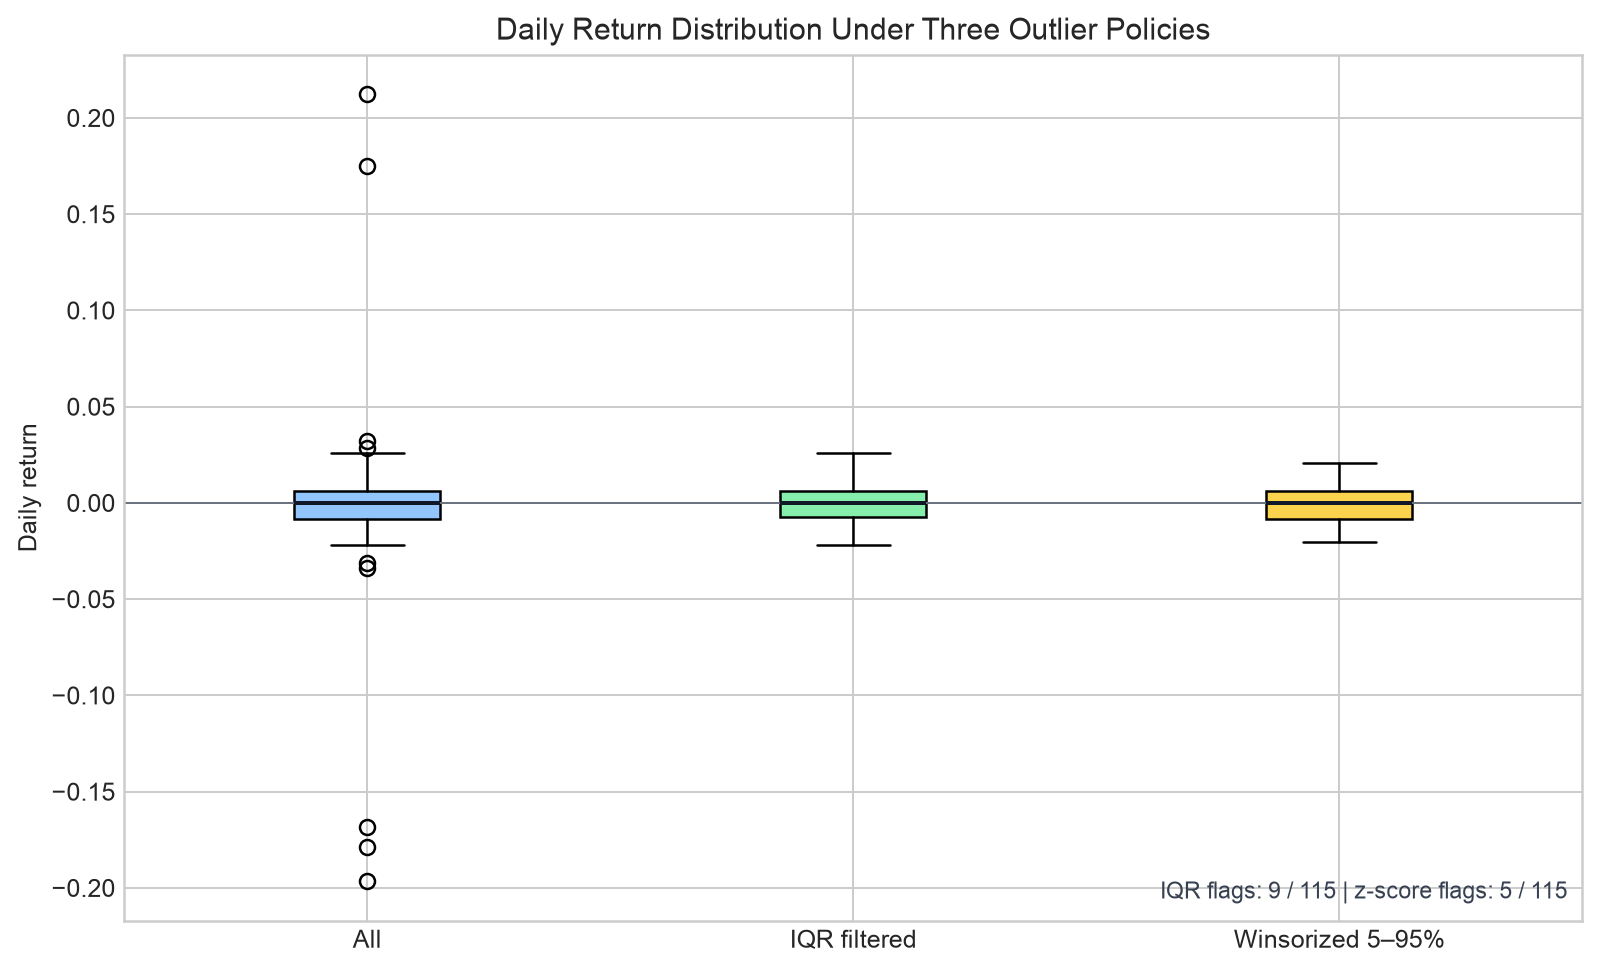

In [8]:
boxplot_path = REPORTS / "outlier_treatment_boxplot.png"
fig, ax = plt.subplots(figsize=(9, 5.5))
box = ax.boxplot(
    [variants["all"], variants["filtered_iqr"], variants["winsorized_5_95"]],
    tick_labels=["All", "IQR filtered", "Winsorized 5–95%"],
    patch_artist=True,
    medianprops={"color": "#111827", "linewidth": 1.6},
)
for patch, color in zip(box["boxes"], ["#93C5FD", "#86EFAC", "#FCD34D"]):
    patch.set_facecolor(color)
ax.axhline(0, color="#6B7280", linewidth=0.8)
ax.set_title("Daily Return Distribution Under Three Outlier Policies")
ax.set_ylabel("Daily return")
ax.text(
    0.99, 0.02, "IQR flags: 9 / 115 | z-score flags: 5 / 115",
    transform=ax.transAxes, ha="right", va="bottom", fontsize=9, color="#374151"
)
fig.tight_layout()
fig.savefig(boxplot_path, dpi=180, bbox_inches="tight")
plt.close(fig)
print("Saved boxplot:", boxplot_path.relative_to(ROOT))
display(Image(filename=str(boxplot_path)))

Saved residual comparison: reports/regression_residuals.png


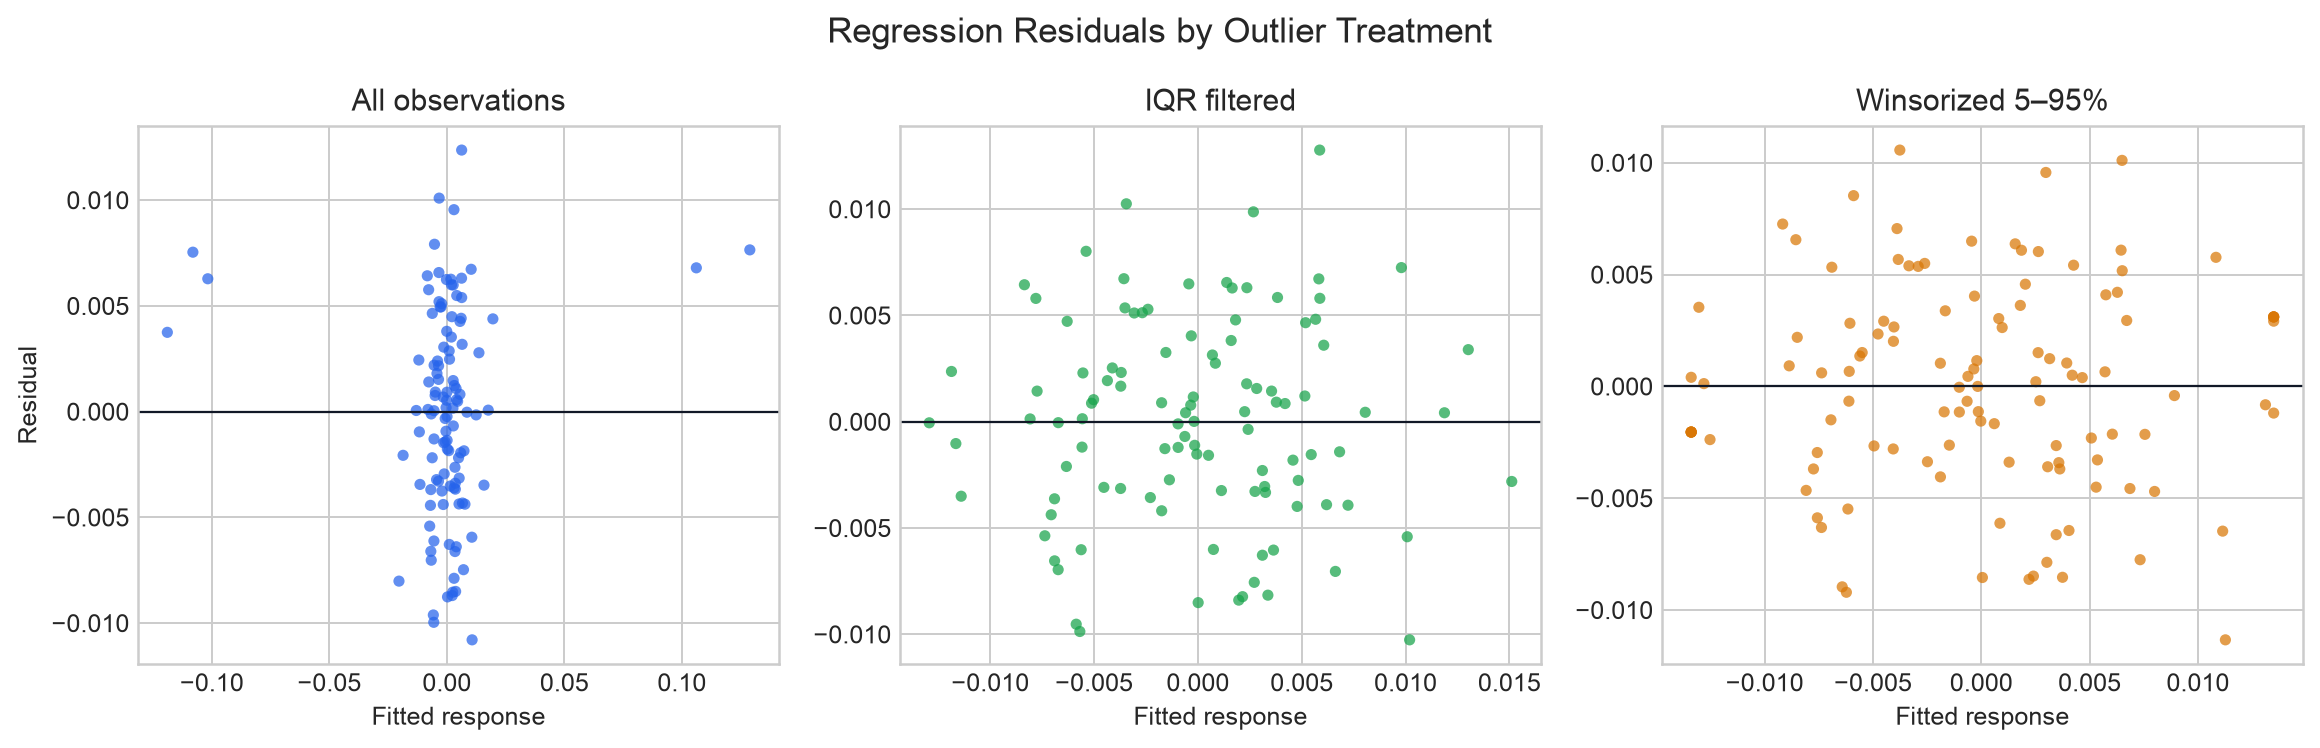

In [9]:
residual_path = REPORTS / "regression_residuals.png"
labels = {
    "all": "All observations",
    "filtered_iqr": "IQR filtered",
    "winsorized_5_95": "Winsorized 5–95%",
}
colors = {
    "all": "#2563EB",
    "filtered_iqr": "#16A34A",
    "winsorized_5_95": "#D97706",
}
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, variant in zip(axes, labels):
    subset = regression_residuals.loc[regression_residuals["variant"] == variant]
    ax.scatter(
        subset["fitted"], subset["residual"],
        s=20, alpha=0.72, color=colors[variant], edgecolor="none"
    )
    ax.axhline(0, color="#111827", linewidth=0.9)
    ax.set_title(labels[variant])
    ax.set_xlabel("Fitted response")
axes[0].set_ylabel("Residual")
fig.suptitle("Regression Residuals by Outlier Treatment", fontsize=14)
fig.tight_layout()
fig.savefig(residual_path, dpi=180, bbox_inches="tight")
plt.close(fig)
print("Saved residual comparison:", residual_path.relative_to(ROOT))
display(Image(filename=str(residual_path)))

## 7. Reflection (≤1 page)

**Choices and assumptions.** I used the conventional IQR multiplier 1.5 and a 3.0 population-z-score threshold because the starter asks for both and they expose different assumptions. IQR depends on quartiles rather than normality; z-score treats distance from the mean in standard-deviation units and is more vulnerable to heavy tails. I also tested 5%/95% winsorization as a row-preserving alternative. These thresholds are sensitivity assumptions, not facts about what constitutes bad data.

**Observed impact.** IQR flags 9 of 115 observations (7.8%): all five injected shocks plus four ordinary but relatively large simulated returns. Z-score flags exactly the five injected shocks, so the methods overlap on five rows but disagree on four. The all-data regression has slope 0.606, R² 0.962, and MAE 0.00395, close to the seeded `0.6 × daily_return` relationship. IQR filtering changes the slope to 0.590 and drops R² to 0.574 while MAE changes only slightly to 0.00385. Winsorizing both variables yields slope 0.650, R² 0.689, and treatment-scale MAE 0.00374. Thus, removal does not automatically produce a “better” model: the shared shocks carry genuine signal here.

**Risks if assumptions are wrong.** Financial returns are often heavy-tailed and regime-dependent, so either detector can label real stress events as abnormal. Removing those dates would understate tail risk and is especially dangerous for the Stage 01 objective, whose target is high-volatility events. Winsorizing retains dates but changes magnitudes and can bias loss estimates, calibration, and stress testing. Conversely, retaining a true data-entry error can dominate a fitted relationship. The correct action therefore requires source validation and business context, not only a statistical flag. In later predictive work, fences, z-score moments, and winsorization cutoffs must be learned on training data only; using the full timeline would leak future distribution information. This regression is contemporaneous, synthetic, and in-sample, so it demonstrates sensitivity rather than forecasting or causality.

In [10]:
required_outputs = [
    raw_path, flags_path, summary_path, metrics_path, boxplot_path, residual_path
]
assert df.shape == (115, 7)
assert not df.isna().any().any()
assert df["date"].is_unique and df["date"].is_monotonic_increasing
assert int(df["outlier_iqr"].sum()) == 9
assert int(df["outlier_zscore"].sum()) == 5
assert int((df["outlier_iqr"] & df["outlier_zscore"]).sum()) == 5
assert set(sensitivity_summary["variant"]) == set(variants)
assert set(regression_metrics["variant"]) == set(regression_inputs)
assert regression_metrics.loc[
    regression_metrics["variant"] == "all", "r2_treatment"
].iloc[0] > 0.9
assert all(path.exists() and path.stat().st_size > 0 for path in required_outputs)

print("Stage 07 function, sensitivity, plot, and artifact checks passed.")

Stage 07 function, sensitivity, plot, and artifact checks passed.
